# 03 Strategy Comparison: Efficient Frontier, Benchmarks, and Recommendation

This notebook consumes `outputs/tables/baseline_strategy_results.csv` (produced by `02_baseline_strategies.ipynb`) and turns the baseline grid search into a decision. It builds:

- an efficient-frontier view of execution cost vs. delta risk across every static-band configuration in the grid;
- benchmark comparisons against the zero-hedge and full-hedge extremes;
- sensitivity tables for band width, execution horizon, impact-cost parameters, and the risk-penalty weight;
- an intraday walk-through of how book delta -- and the resulting delta PnL -- actually evolves under each strategy;
- a final recommendation for the baseline static-band policy.

Primary input: `outputs/tables/baseline_strategy_results.csv`.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

RESULTS_PATH = OUTPUT_TABLE_DIR / 'baseline_strategy_results.csv'
DELTA_ARRIVALS_PATH = PROCESSED_DIR / 'executed_trade_delta_arrivals.csv'
MARKET_INPUTS_PATH = PROCESSED_DIR / 'market_inputs_2026.csv'

# Fixed simulation constants from 02_baseline_strategies.ipynb (needed to
# recompute combined_loss and rescale costs for the sensitivity grids below).
BAR_MINUTES = 5
SPREAD_BPS = 1.0
IMPACT_ALPHA = 0.05
IMPACT_BETA = 0.5
LAMBDA_RISK = 1e-8

# Chart palette (validated categorical + ordinal ramps).
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID_COLOR = '#e1e0d9'
COLOR_ZERO_HEDGE = '#2a78d6'
COLOR_FULL_HEDGE = '#1baf7a'
COLOR_STATIC_BAND = '#eda100'
BAND_RAMP = ['#dba149', '#cf8a1f', '#b87200', '#965d00']  # ordinal: light -> dark as band widens

print(PROJECT_ROOT)

C:\Users\chung\Downloads\JPM delta hedging project\JPM_Optimal_Intraday_Delta_Hedging_Strategy


## 2. Load Baseline Strategy Results

In [2]:
results_df = pd.read_csv(RESULTS_PATH)
results_df['trade_date'] = pd.to_datetime(results_df['trade_date'])

n_days = results_df['trade_date'].nunique()
print(f'Strategy-day records: {len(results_df):,} across {n_days:,} trading days')
results_df.head()

Strategy-day records: 2,652 across 102 trading days


,trade_date,strategy,band,method,horizon_minutes,execution_cost,spread_cost,impact_cost,delta_risk,combined_loss,n_triggers,total_abs_hedge_delta,eod_delta_before_flatten
0,2026-01-02,zero_hedge,NaN,close_only,0,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467
1,2026-01-02,full_hedge,0.0,immediate,0,260666.580464,2598.040545,258068.539919,0.000000,260666.580464,49,7533.402177,0.000000
2,2026-01-02,static_band,25000.0,twap,15,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467
3,2026-01-02,static_band,25000.0,twap,30,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467
4,2026-01-02,static_band,25000.0,twap,60,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467


## 3. Aggregate Across Days by Strategy Configuration

In [3]:
config_summary = (
    results_df.groupby(['strategy', 'band', 'method', 'horizon_minutes'], dropna=False)
    .agg(
        execution_cost=('execution_cost', 'sum'),
        spread_cost=('spread_cost', 'sum'),
        impact_cost=('impact_cost', 'sum'),
        delta_risk=('delta_risk', 'sum'),
        combined_loss=('combined_loss', 'sum'),
        n_triggers=('n_triggers', 'sum'),
        total_abs_hedge_delta=('total_abs_hedge_delta', 'sum'),
        avg_eod_delta_before_flatten=('eod_delta_before_flatten', 'mean'),
    )
    .reset_index()
    .sort_values('combined_loss')
)

zero_hedge = config_summary.loc[config_summary['strategy'].eq('zero_hedge')].iloc[0]
full_hedge = config_summary.loc[config_summary['strategy'].eq('full_hedge')].iloc[0]
static_band = config_summary.loc[config_summary['strategy'].eq('static_band')].copy()
best_static = static_band.sort_values('combined_loss').iloc[0]

config_summary.head(10)

,strategy,band,method,horizon_minutes,execution_cost,spread_cost,impact_cost,delta_risk,combined_loss,n_triggers,total_abs_hedge_delta,avg_eod_delta_before_flatten
3,static_band,25000.0,twap,60,8.976511e+06,133222.978546,8.843288e+06,181762.438035,8.976511e+06,3,380265.897362,250.734835
6,static_band,25000.0,vwap,60,8.999623e+06,133223.112113,8.866400e+06,180759.142836,8.999623e+06,2,380265.897362,250.734835
2,static_band,25000.0,twap,30,9.189494e+06,133222.933434,9.056271e+06,180115.162569,9.189494e+06,1,380265.897362,296.235921
5,static_band,25000.0,vwap,30,9.206424e+06,133223.010235,9.073201e+06,180213.110133,9.206424e+06,1,380265.897362,296.235921
1,static_band,25000.0,twap,15,9.422547e+06,133223.530859,9.289323e+06,178676.337913,9.422547e+06,1,380265.897362,296.235921
4,static_band,25000.0,vwap,15,9.432057e+06,133223.197960,9.298834e+06,178520.056388,9.432057e+06,1,380265.897362,296.235921
7,static_band,50000.0,twap,15,1.031922e+07,133214.406552,1.018601e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748
8,static_band,50000.0,twap,30,1.031922e+07,133214.406552,1.018601e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748
12,static_band,50000.0,vwap,60,1.031922e+07,133214.406552,1.018601e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748
9,static_band,50000.0,twap,60,1.031922e+07,133214.406552,1.018601e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748


## 4. Efficient Frontier: Execution Cost vs. Delta Risk

Each point below is one static-band configuration (band width x execution method x horizon), aggregated over the full backtest period. Band is an ordinal, magnitude-like variable, so it is encoded as a single-hue ramp (light = tight band, dark = wide band); execution method is encoded separately by marker shape so the two dimensions don't compete for the same channel. The zero-hedge and full-hedge benchmarks are overlaid as stars. The dashed line traces the Pareto frontier -- configurations where no other point has both lower cost and lower risk.

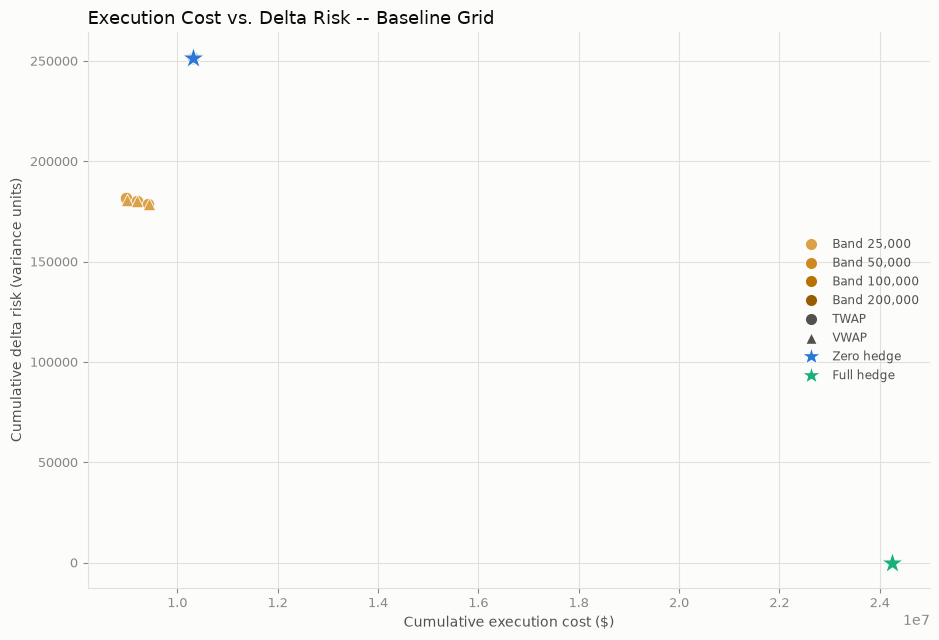

Wrote figure to outputs\figures\efficient_frontier_cost_vs_risk.png
Pareto-efficient configs: 5 of 24


,band,method,horizon_minutes,execution_cost,delta_risk,combined_loss
0,25000.0,twap,60,8.976511e+06,181762.438035,8.976511e+06
1,25000.0,vwap,60,8.999623e+06,180759.142836,8.999623e+06
2,25000.0,twap,30,9.189494e+06,180115.162569,9.189494e+06
4,25000.0,twap,15,9.422547e+06,178676.337913,9.422547e+06
5,25000.0,vwap,15,9.432057e+06,178520.056388,9.432057e+06


In [4]:
BAND_ORDER = sorted(static_band['band'].unique())
BAND_COLORS = dict(zip(BAND_ORDER, BAND_RAMP))
METHOD_MARKERS = {'twap': 'o', 'vwap': '^'}


def pareto_frontier(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """Non-dominated points when minimizing both x_col and y_col."""
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    keep = []
    best_y = np.inf
    for i, row in ordered.iterrows():
        if row[y_col] < best_y:
            keep.append(i)
            best_y = row[y_col]
    return ordered.loc[keep]


frontier = pareto_frontier(static_band, 'execution_cost', 'delta_risk')

fig, ax = plt.subplots(figsize=(9.5, 6.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

for band in BAND_ORDER:
    for method, marker in METHOD_MARKERS.items():
        subset = static_band.loc[static_band['band'].eq(band) & static_band['method'].eq(method)]
        ax.scatter(
            subset['execution_cost'], subset['delta_risk'], color=BAND_COLORS[band], marker=marker,
            s=80, edgecolor=SURFACE, linewidth=0.6, zorder=3,
        )

ax.plot(frontier['execution_cost'], frontier['delta_risk'], color=INK_MUTED, linewidth=1, linestyle='--', zorder=2)

ax.scatter(zero_hedge['execution_cost'], zero_hedge['delta_risk'], color=COLOR_ZERO_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)
ax.scatter(full_hedge['execution_cost'], full_hedge['delta_risk'], color=COLOR_FULL_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)

band_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=BAND_COLORS[band], markeredgecolor=SURFACE, markersize=9, label=f'Band {band:,.0f}')
    for band in BAND_ORDER
]
method_handles = [
    plt.Line2D([0], [0], marker=marker, linestyle='', markerfacecolor=INK_SECONDARY, markeredgecolor=SURFACE, markersize=9, label=method.upper())
    for method, marker in METHOD_MARKERS.items()
]
benchmark_handles = [
    plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_ZERO_HEDGE, markeredgecolor=SURFACE, markersize=15, label='Zero hedge'),
    plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_FULL_HEDGE, markeredgecolor=SURFACE, markersize=15, label='Full hedge'),
]

legend = ax.legend(handles=band_handles + method_handles + benchmark_handles, loc='center right', frameon=False, fontsize=8.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

ax.set_title('Execution Cost vs. Delta Risk -- Baseline Grid', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_xlabel('Cumulative execution cost ($)', color=INK_SECONDARY, fontsize=10)
ax.set_ylabel('Cumulative delta risk (variance units)', color=INK_SECONDARY, fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'efficient_frontier_cost_vs_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')
print(f'Pareto-efficient configs: {len(frontier)} of {len(static_band)}')
frontier[['band', 'method', 'horizon_minutes', 'execution_cost', 'delta_risk', 'combined_loss']]

## 5. Benchmark Comparison vs. Zero Hedge and Full Hedge

The panels below compare the best static-band configuration (lowest `combined_loss`) against the two benchmarks on each objective separately -- cost and risk sit on different scales, so they get their own axes rather than a dual-axis chart.

In [5]:
benchmark_table = pd.DataFrame([
    {'strategy': 'Zero hedge', 'execution_cost': zero_hedge['execution_cost'], 'delta_risk': zero_hedge['delta_risk'], 'combined_loss': zero_hedge['combined_loss']},
    {'strategy': 'Full hedge', 'execution_cost': full_hedge['execution_cost'], 'delta_risk': full_hedge['delta_risk'], 'combined_loss': full_hedge['combined_loss']},
    {
        'strategy': f"Static band {best_static['band']:,.0f} ({best_static['method'].upper()}, {best_static['horizon_minutes']}min)",
        'execution_cost': best_static['execution_cost'], 'delta_risk': best_static['delta_risk'], 'combined_loss': best_static['combined_loss'],
    },
])
benchmark_table['cost_vs_zero_hedge_pct'] = (benchmark_table['execution_cost'] / zero_hedge['execution_cost'] - 1) * 100
benchmark_table['risk_vs_zero_hedge_pct'] = (benchmark_table['delta_risk'] / zero_hedge['delta_risk'] - 1) * 100
benchmark_table['cost_vs_full_hedge_pct'] = (benchmark_table['execution_cost'] / full_hedge['execution_cost'] - 1) * 100

benchmark_table

,strategy,execution_cost,delta_risk,combined_loss,cost_vs_zero_hedge_pct,risk_vs_zero_hedge_pct,cost_vs_full_hedge_pct
0,Zero hedge,1.031922e+07,251665.797568,1.031922e+07,0.000000,0.000000,-57.426976
1,Full hedge,2.423887e+07,0.000000,2.423887e+07,134.890524,-100.000000,0.000000
2,"Static band 25,000 (TWAP, 60min)",8.976511e+06,181762.438035,8.976511e+06,-13.011730,-27.776265,-62.966463


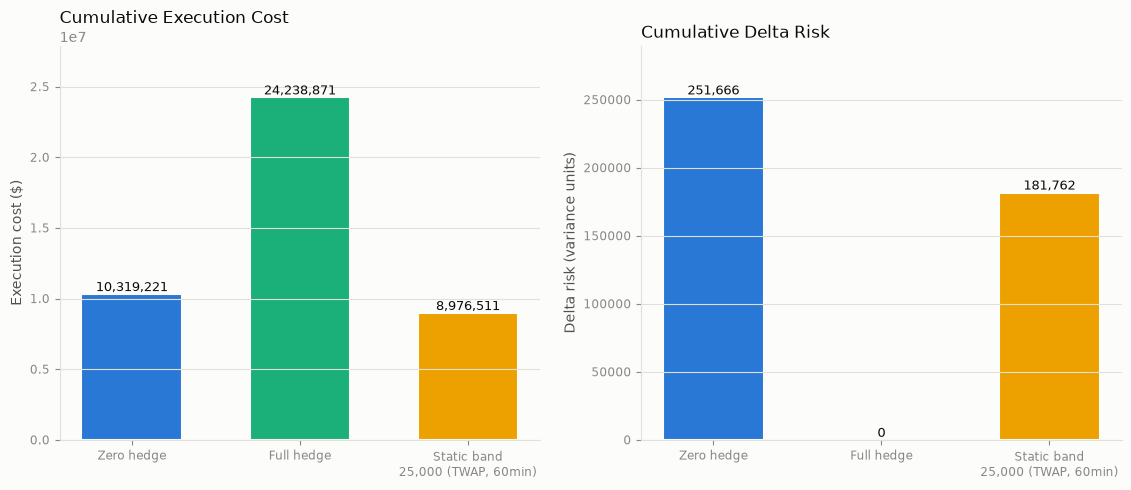

Wrote figure to outputs\figures\benchmark_comparison_cost_risk.png


In [6]:
labels = ['Zero hedge', 'Full hedge', f"Static band\n{best_static['band']:,.0f} ({best_static['method'].upper()}, {best_static['horizon_minutes']}min)"]
colors = [COLOR_ZERO_HEDGE, COLOR_FULL_HEDGE, COLOR_STATIC_BAND]
cost_values = [zero_hedge['execution_cost'], full_hedge['execution_cost'], best_static['execution_cost']]
risk_values = [zero_hedge['delta_risk'], full_hedge['delta_risk'], best_static['delta_risk']]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
fig.patch.set_facecolor(SURFACE)

for ax, values, title, ylabel in (
    (axes[0], cost_values, 'Cumulative Execution Cost', 'Execution cost ($)'),
    (axes[1], risk_values, 'Cumulative Delta Risk', 'Delta risk (variance units)'),
):
    ax.set_facecolor(SURFACE)
    bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor=SURFACE, linewidth=1.5)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.0f}', ha='center', va='bottom', color=INK_PRIMARY, fontsize=9)
    ax.set_title(title, color=INK_PRIMARY, fontsize=12, loc='left')
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)
    ax.set_ylim(top=max(values) * 1.15)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID_COLOR)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)

fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'benchmark_comparison_cost_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 6. Sensitivity: Band Width

Grouping the static-band results by band width alone (averaged across method and horizon) shows how quickly the grid saturates: any band wide enough to never be breached collapses to the zero-hedge outcome exactly, since the only hedge that ever fires is the end-of-day flatten.

In [7]:
band_sensitivity = (
    static_band.groupby('band')
    .agg(
        execution_cost=('execution_cost', 'mean'),
        delta_risk=('delta_risk', 'mean'),
        combined_loss=('combined_loss', 'mean'),
        n_triggers=('n_triggers', 'mean'),
    )
    .reset_index()
    .sort_values('band')
)
band_sensitivity['pct_of_backtest_days_triggered'] = band_sensitivity['n_triggers'] / n_days * 100

never_triggered = band_sensitivity.loc[band_sensitivity['n_triggers'].eq(0), 'band'].tolist()
if never_triggered:
    print(f"Bands that are never breached in the backtest (identical to zero hedge): {never_triggered}")

band_sensitivity

Bands that are never breached in the backtest (identical to zero hedge): [50000.0, 100000.0, 200000.0]


,band,execution_cost,delta_risk,combined_loss,n_triggers,pct_of_backtest_days_triggered
0,25000.0,9.204443e+06,180007.707979,9.204443e+06,1.5,1.470588
1,50000.0,1.031922e+07,251665.797568,1.031922e+07,0.0,0.000000
2,100000.0,1.031922e+07,251665.797568,1.031922e+07,0.0,0.000000
3,200000.0,1.031922e+07,251665.797568,1.031922e+07,0.0,0.000000


## 7. Sensitivity: Execution Horizon

Only the band that actually binds (25,000 contracts -- see Section 6) shows a real cost/risk trade-off across horizons, so the horizon sweep below is restricted to that band. Widening the unwind horizon lowers execution cost (fewer contracts per child order, so lower participation rate and lower impact cost) but leaves book delta unhedged for longer, which nudges delta risk up slightly.

In [8]:
binding_band = band_sensitivity.loc[band_sensitivity['n_triggers'].gt(0), 'band'].min()

horizon_sensitivity = (
    static_band.loc[static_band['band'].eq(binding_band)]
    .groupby('horizon_minutes')
    .agg(
        execution_cost=('execution_cost', 'mean'),
        delta_risk=('delta_risk', 'mean'),
        combined_loss=('combined_loss', 'mean'),
        n_triggers=('n_triggers', 'mean'),
    )
    .reset_index()
    .sort_values('horizon_minutes')
)

print(f'Restricted to band = {binding_band:,.0f} (the only band triggered in the backtest)')
horizon_sensitivity

Restricted to band = 25,000 (the only band triggered in the backtest)


,horizon_minutes,execution_cost,delta_risk,combined_loss,n_triggers
0,15,9.427302e+06,178598.197150,9.427302e+06,1.0
1,30,9.197959e+06,180164.136351,9.197959e+06,1.0
2,60,8.988067e+06,181260.790436,8.988067e+06,2.5


## 8. Sensitivity: Impact-Cost Parameters

`spread_cost` and `impact_cost` are stored separately in the results file, and each scales exactly linearly with its underlying parameter (`SPREAD_BPS` and `IMPACT_ALPHA` respectively -- see `estimate_child_order_cost` in notebook 02). That means each can be rescaled analytically here, without re-running the per-bar simulation, by multiplying the realized cost component and recomputing `execution_cost` and `combined_loss`. `IMPACT_BETA` (the nonlinear participation exponent) is held fixed: rescaling it would require the per-order participation rate, which isn't retained at the daily-aggregate grain of `baseline_strategy_results.csv`.

In [9]:
SPREAD_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]
IMPACT_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]


def rescale_costs(df: pd.DataFrame, spread_mult: float = 1.0, impact_mult: float = 1.0) -> pd.DataFrame:
    out = df.copy()
    out['execution_cost'] = out['spread_cost'] * spread_mult + out['impact_cost'] * impact_mult
    out['combined_loss'] = out['execution_cost'] + LAMBDA_RISK * out['delta_risk']
    return out


def best_static_row(rescaled: pd.DataFrame) -> pd.Series:
    return rescaled.loc[rescaled['strategy'].eq('static_band')].sort_values('combined_loss').iloc[0]


spread_rows = []
for mult in SPREAD_MULTIPLIERS:
    rescaled = rescale_costs(config_summary, spread_mult=mult, impact_mult=1.0)
    best = best_static_row(rescaled)
    zero = rescaled.loc[rescaled['strategy'].eq('zero_hedge')].iloc[0]
    spread_rows.append({
        'spread_multiplier': mult,
        'implied_spread_bps': SPREAD_BPS * mult,
        'best_band': best['band'], 'best_method': best['method'], 'best_horizon_minutes': best['horizon_minutes'],
        'static_band_cost': best['execution_cost'], 'zero_hedge_cost': zero['execution_cost'],
        'static_band_advantage_pct': (1 - best['execution_cost'] / zero['execution_cost']) * 100,
    })
spread_sensitivity = pd.DataFrame(spread_rows)

impact_rows = []
for mult in IMPACT_MULTIPLIERS:
    rescaled = rescale_costs(config_summary, spread_mult=1.0, impact_mult=mult)
    best = best_static_row(rescaled)
    zero = rescaled.loc[rescaled['strategy'].eq('zero_hedge')].iloc[0]
    impact_rows.append({
        'impact_multiplier': mult,
        'implied_impact_alpha': IMPACT_ALPHA * mult,
        'best_band': best['band'], 'best_method': best['method'], 'best_horizon_minutes': best['horizon_minutes'],
        'static_band_cost': best['execution_cost'], 'zero_hedge_cost': zero['execution_cost'],
        'static_band_advantage_pct': (1 - best['execution_cost'] / zero['execution_cost']) * 100,
    })
impact_sensitivity = pd.DataFrame(impact_rows)

print('Spread-cost sensitivity (impact held at 1.0x):')
display(spread_sensitivity)
print()
print('Impact-cost sensitivity (spread held at 1.0x):')
display(impact_sensitivity)

Spread-cost sensitivity (impact held at 1.0x):


,spread_multiplier,implied_spread_bps,best_band,best_method,best_horizon_minutes,static_band_cost,zero_hedge_cost,static_band_advantage_pct
0,0.5,0.5,25000.0,twap,60,8.909900e+06,1.025261e+07,13.096304
1,1.0,1.0,25000.0,twap,60,8.976511e+06,1.031922e+07,13.011730
2,2.0,2.0,25000.0,twap,60,9.109734e+06,1.045244e+07,12.845816
3,4.0,4.0,25000.0,twap,60,9.376180e+06,1.071886e+07,12.526360



Impact-cost sensitivity (spread held at 1.0x):


,impact_multiplier,implied_impact_alpha,best_band,best_method,best_horizon_minutes,static_band_cost,zero_hedge_cost,static_band_advantage_pct
0,0.5,0.025,25000.0,twap,60,4.554867e+06,5.226218e+06,12.845816
1,1.0,0.050,25000.0,twap,60,8.976511e+06,1.031922e+07,13.011730
2,2.0,0.100,25000.0,twap,60,1.781980e+07,2.050523e+07,13.096304
3,4.0,0.200,25000.0,twap,60,3.550638e+07,4.087724e+07,13.139005


## 9. Sensitivity: Risk-Penalty Weight (Lambda)

`combined_loss = execution_cost + LAMBDA_RISK * delta_risk`, and both terms are already stored per configuration, so the risk-penalty weight can be swept analytically as well. This shows how large the risk aversion would have to get before the recommendation below changes.

In [10]:
LAMBDA_GRID = [1e-8, 1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0]

lambda_rows = []
for lam in LAMBDA_GRID:
    rescaled = config_summary.copy()
    rescaled['combined_loss'] = rescaled['execution_cost'] + lam * rescaled['delta_risk']
    winner = rescaled.sort_values('combined_loss').iloc[0]
    lambda_rows.append({
        'lambda_risk': lam,
        'winning_strategy': winner['strategy'],
        'band': winner['band'], 'method': winner['method'], 'horizon_minutes': winner['horizon_minutes'],
        'combined_loss': winner['combined_loss'],
    })
lambda_sensitivity = pd.DataFrame(lambda_rows)

breakeven_lambda = (full_hedge['execution_cost'] - best_static['execution_cost']) / best_static['delta_risk']
print(f'Current calibration: LAMBDA_RISK = {LAMBDA_RISK:g}')
print(f'Full hedge only overtakes the best static-band config once LAMBDA_RISK exceeds {breakeven_lambda:,.2f}')
print(f'  -- a factor of {breakeven_lambda / LAMBDA_RISK:,.0f}x higher than the current calibration.')
print()
lambda_sensitivity

Current calibration: LAMBDA_RISK = 1e-08
Full hedge only overtakes the best static-band config once LAMBDA_RISK exceeds 83.97
  -- a factor of 8,396,872,396x higher than the current calibration.



,lambda_risk,winning_strategy,band,method,horizon_minutes,combined_loss
0,1.000000e-08,static_band,25000.0,twap,60,8.976511e+06
1,1.000000e-06,static_band,25000.0,twap,60,8.976512e+06
2,1.000000e-04,static_band,25000.0,twap,60,8.976530e+06
3,1.000000e-02,static_band,25000.0,twap,60,8.978329e+06
4,1.000000e+00,static_band,25000.0,twap,60,9.158274e+06
5,1.000000e+01,static_band,25000.0,twap,60,1.079414e+07
6,1.000000e+02,full_hedge,0.0,immediate,0,2.423887e+07


## 10. Rebuild the Intraday Per-Bar Grid

`baseline_strategy_results.csv` is aggregated to one row per strategy-day, so it has no bar-level detail. The intraday walk-through in the next two sections needs book delta at every 5-minute bar, so this section reloads the delta-arrival and market-bar tables that notebook 02 already persisted (`executed_trade_delta_arrivals.csv`, `market_inputs_2026.csv`) and rebuilds the same per-bar grid, rather than re-deriving deltas from raw option trades.

In [11]:
def build_delta_bar_grid(delta_arrivals: pd.DataFrame, market: pd.DataFrame) -> pd.DataFrame:
    arrivals = (
        delta_arrivals.groupby('bar_time', as_index=False)
        .agg(
            option_delta_arrival=('signed_delta_contracts', 'sum'),
            option_delta_notional=('signed_delta_notional', 'sum'),
            n_option_trades=('trade_id', 'count'),
        )
    )
    grid = market.rename(columns={'timestamp_et': 'bar_time'}).copy()
    grid = grid.merge(arrivals, on='bar_time', how='left')
    grid[['option_delta_arrival', 'option_delta_notional', 'n_option_trades']] = grid[
        ['option_delta_arrival', 'option_delta_notional', 'n_option_trades']
    ].fillna(0.0)
    grid['trade_date'] = pd.to_datetime(grid['trade_date'])
    return grid.sort_values('bar_time').reset_index(drop=True)


def make_child_schedule(parent_delta: float, start_idx: int, day_grid: pd.DataFrame, horizon_minutes: int, method: str) -> pd.DataFrame:
    n_child = max(int(horizon_minutes / BAR_MINUTES), 1)
    idx = list(range(start_idx, min(start_idx + n_child, len(day_grid))))
    if not idx:
        return pd.DataFrame(columns=['idx', 'hedge_delta'])

    if method == 'twap':
        weights = np.ones(len(idx), dtype=float) / len(idx)
    elif method == 'vwap':
        volume = day_grid.loc[idx, 'es1_volume_5m'].clip(lower=0).fillna(0).to_numpy(dtype=float)
        weights = volume / volume.sum() if volume.sum() > 0 else np.ones(len(idx), dtype=float) / len(idx)
    else:
        raise ValueError(f'Unknown execution method: {method}')

    return pd.DataFrame({'idx': idx, 'hedge_delta': parent_delta * weights})


def compute_delta_pnl(book_delta: np.ndarray, price: np.ndarray) -> np.ndarray:
    """Cumulative mark-to-market PnL from carrying book_delta[t-1] through the price move to t."""
    price_diff = np.diff(price, prepend=price[0])
    delta_prev = np.concatenate([[0.0], book_delta[:-1]])
    return np.cumsum(delta_prev * price_diff)


delta_arrivals = pd.read_csv(DELTA_ARRIVALS_PATH)
delta_arrivals['bar_time'] = pd.to_datetime(delta_arrivals['bar_time'])

market = pd.read_csv(MARKET_INPUTS_PATH)
market['timestamp_et'] = pd.to_datetime(market['timestamp_et'])
market['trade_date'] = pd.to_datetime(market['trade_date'])

bar_grid = build_delta_bar_grid(delta_arrivals, market)
print(f'Bars: {len(bar_grid):,} across {bar_grid["trade_date"].nunique():,} trading days')
bar_grid[['bar_time', 'trade_date', 'es1_price', 'es1_volume_5m', 'option_delta_arrival', 'n_option_trades']].head()

Bars: 8,364 across 102 trading days


,bar_time,trade_date,es1_price,es1_volume_5m,option_delta_arrival,n_option_trades
0,2026-01-02 09:30:00,2026-01-02,6918.75,40615.0,0.000000,0.0
1,2026-01-02 09:35:00,2026-01-02,6915.25,24586.0,0.000000,0.0
2,2026-01-02 09:40:00,2026-01-02,6919.75,20690.0,5.538310,1.0
3,2026-01-02 09:45:00,2026-01-02,6931.75,33464.0,-123.282465,1.0
4,2026-01-02 09:50:00,2026-01-02,6932.75,25026.0,-142.357479,4.0


## 11. Intraday Delta Path: How Book Delta Evolves Across Strategies

This section plots book delta across the trading day for three regimes: zero hedge (no rebalancing), full hedge (immediate offset of every arrival), and a static band strategy. The cost-optimal band from the grid above (25,000 contracts) rarely breaches even on busy days, so it makes a flat, uninformative chart. Instead this section uses a tighter illustrative band (10,000 contracts, TWAP, 60-minute horizon) and picks the trading day where that band produces the largest divergence in cumulative delta PnL from zero hedge, so the plot actually shows the trigger -> TWAP unwind -> re-accumulation cycle and its economic effect, not just a busy-but-similar day.

In [12]:
def simulate_static_band_day_path(day_grid: pd.DataFrame, band: float, method: str, horizon_minutes: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Replay the static-band simulator, recording book delta at every bar for plotting."""
    book_delta = 0.0
    active_schedule = pd.DataFrame(columns=['idx', 'hedge_delta'])
    day_grid = day_grid.reset_index(drop=True).copy()
    path = []
    triggers = []

    for i, row in day_grid.iterrows():
        book_delta += float(row.option_delta_arrival)

        scheduled = active_schedule.loc[active_schedule['idx'].eq(i), 'hedge_delta']
        hedge_delta = float(scheduled.sum()) if not scheduled.empty else 0.0
        if hedge_delta != 0.0:
            book_delta += hedge_delta

        if abs(book_delta) > band:
            parent_order = -book_delta
            active_schedule = make_child_schedule(parent_order, i + 1, day_grid, horizon_minutes, method)
            triggers.append({'bar_time': row.bar_time, 'book_delta': book_delta})

        path.append({'bar_time': row.bar_time, 'book_delta': book_delta})

    return pd.DataFrame(path), pd.DataFrame(triggers, columns=['bar_time', 'book_delta'])

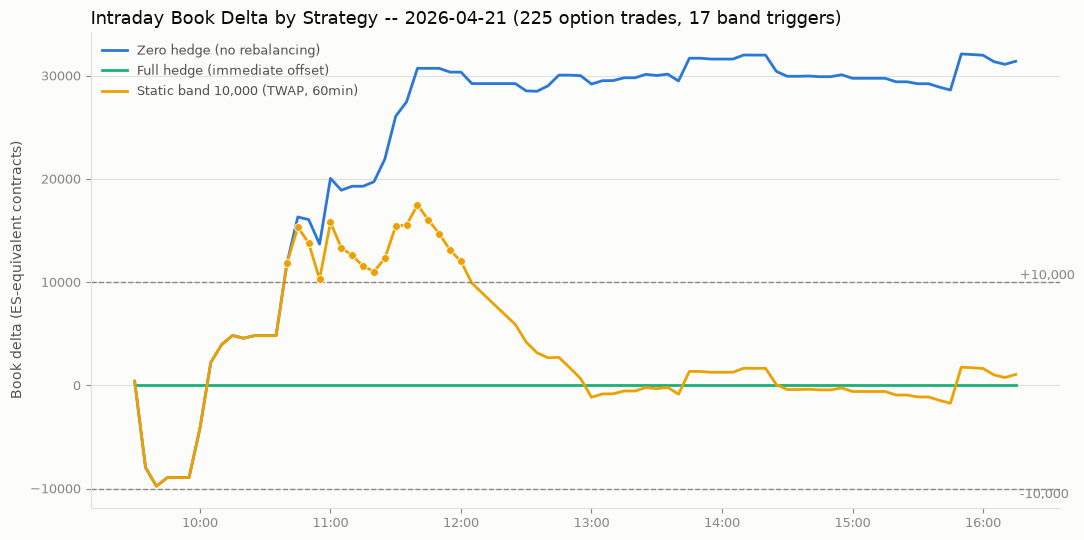

Wrote figure to outputs\figures\intraday_delta_path_by_strategy.png


In [13]:
ILLUSTRATIVE_BAND = 10_000
ILLUSTRATIVE_METHOD = 'twap'
ILLUSTRATIVE_HORIZON = 60
MIN_TRIGGERS_FOR_SAMPLE_DAY = 2

# Pick the trading day where the illustrative band diverges most from zero
# hedge in cumulative delta PnL, so the chart shows both a real trigger ->
# unwind -> re-accumulation cycle and a visible economic difference between
# the two strategies (rather than just the busiest day by trade count).
candidate_days = []
for trade_date, day_grid in bar_grid.groupby('trade_date'):
    day_grid = day_grid.sort_values('bar_time').reset_index(drop=True)
    day_zero_delta = day_grid['option_delta_arrival'].cumsum().to_numpy()
    day_static_path, day_triggers = simulate_static_band_day_path(day_grid, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)
    if len(day_triggers) < MIN_TRIGGERS_FOR_SAMPLE_DAY:
        continue
    day_price = day_grid['es1_price'].to_numpy()
    day_zero_pnl = compute_delta_pnl(day_zero_delta, day_price)
    day_static_pnl = compute_delta_pnl(day_static_path['book_delta'].to_numpy(), day_price)
    candidate_days.append({
        'trade_date': trade_date,
        'n_option_trades': int(day_grid['n_option_trades'].sum()),
        'n_triggers': len(day_triggers),
        'max_pnl_gap': np.max(np.abs(day_zero_pnl - day_static_pnl)),
    })

candidate_days_df = pd.DataFrame(candidate_days)
sample_day = candidate_days_df.sort_values('max_pnl_gap', ascending=False)['trade_date'].iloc[0]

day_grid_sample = (
    bar_grid.loc[bar_grid['trade_date'].eq(sample_day)]
    .sort_values('bar_time')
    .reset_index(drop=True)
)

zero_hedge_delta = day_grid_sample['option_delta_arrival'].cumsum().to_numpy()
full_hedge_delta = np.zeros(len(day_grid_sample))

static_band_path, static_band_triggers = simulate_static_band_day_path(
    day_grid_sample, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON
)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_grid_sample['bar_time'], zero_hedge_delta, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_grid_sample['bar_time'], full_hedge_delta, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (immediate offset)')
ax.plot(
    static_band_path['bar_time'], static_band_path['book_delta'], color=COLOR_STATIC_BAND, linewidth=2,
    label=f'Static band {ILLUSTRATIVE_BAND:,.0f} ({ILLUSTRATIVE_METHOD.upper()}, {ILLUSTRATIVE_HORIZON}min)',
)
if not static_band_triggers.empty:
    ax.scatter(
        static_band_triggers['bar_time'], static_band_triggers['book_delta'], color=COLOR_STATIC_BAND, s=32,
        zorder=5, edgecolor=SURFACE, linewidth=0.6,
    )

ax.axhline(ILLUSTRATIVE_BAND, color=INK_MUTED, linestyle='--', linewidth=1)
ax.axhline(-ILLUSTRATIVE_BAND, color=INK_MUTED, linestyle='--', linewidth=1)
ax.text(day_grid_sample['bar_time'].iloc[-1], ILLUSTRATIVE_BAND, f' +{ILLUSTRATIVE_BAND:,.0f}', color=INK_MUTED, fontsize=9, va='bottom')
ax.text(day_grid_sample['bar_time'].iloc[-1], -ILLUSTRATIVE_BAND, f' -{ILLUSTRATIVE_BAND:,.0f}', color=INK_MUTED, fontsize=9, va='top')

n_trades_sample = int(day_grid_sample['n_option_trades'].sum())
ax.set_title(
    f'Intraday Book Delta by Strategy -- {sample_day.date()} ({n_trades_sample:,} option trades, {len(static_band_triggers)} band triggers)',
    color=INK_PRIMARY, fontsize=13, loc='left',
)
ax.set_ylabel('Book delta (ES-equivalent contracts)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_path_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 12. Delta PnL: The Cost of Carrying Unhedged Exposure

Book delta by itself only shows exposure; it doesn't show what that exposure costs or earns as the underlying moves. This section converts each strategy's book-delta path from Section 11 into a cumulative delta PnL: the mark-to-market gain or loss from carrying the prior bar's book delta through the next price move, `pnl_bar = book_delta[t-1] * (es1_price[t] - es1_price[t-1])`, cumulated across the day. Full hedge stays flat at zero PnL by construction (it never carries delta between bars); zero hedge and the static band show how much directional P&L swings the book absorbs by not being immediately flat.

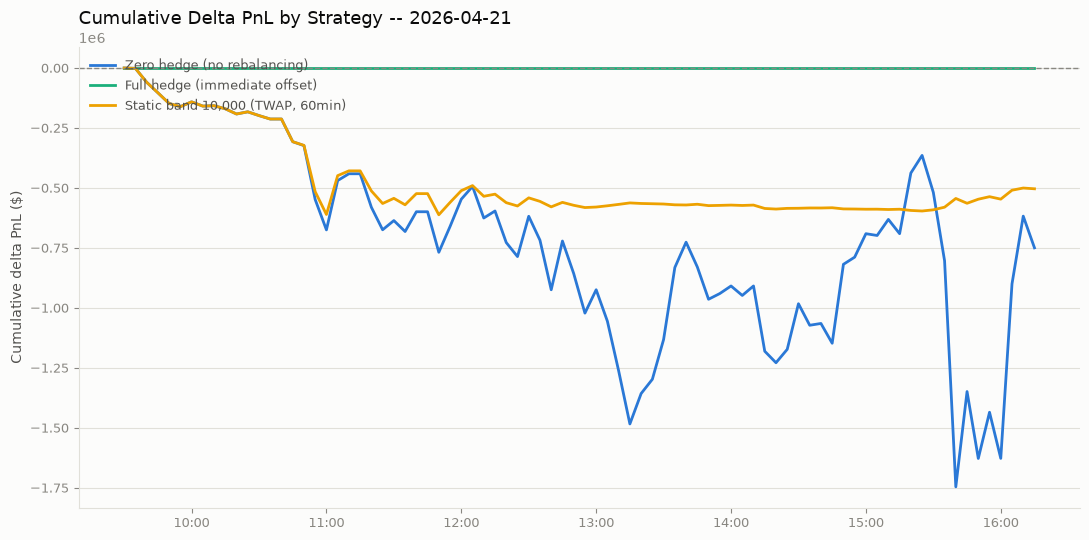

Wrote figure to outputs\figures\intraday_delta_pnl_by_strategy.png
End-of-day delta PnL -- zero hedge: -749,651, full hedge: 0, static band: -503,527


In [14]:
price_sample = day_grid_sample['es1_price'].to_numpy()

zero_hedge_pnl = compute_delta_pnl(zero_hedge_delta, price_sample)
full_hedge_pnl = compute_delta_pnl(full_hedge_delta, price_sample)
static_band_pnl = compute_delta_pnl(static_band_path['book_delta'].to_numpy(), price_sample)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_grid_sample['bar_time'], zero_hedge_pnl, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_grid_sample['bar_time'], full_hedge_pnl, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (immediate offset)')
ax.plot(
    day_grid_sample['bar_time'], static_band_pnl, color=COLOR_STATIC_BAND, linewidth=2,
    label=f'Static band {ILLUSTRATIVE_BAND:,.0f} ({ILLUSTRATIVE_METHOD.upper()}, {ILLUSTRATIVE_HORIZON}min)',
)
ax.axhline(0, color=INK_MUTED, linestyle='--', linewidth=1)

ax.set_title(f'Cumulative Delta PnL by Strategy -- {sample_day.date()}', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Cumulative delta PnL ($)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

pnl_fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_pnl_by_strategy.png'
fig.savefig(pnl_fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {pnl_fig_path.relative_to(PROJECT_ROOT)}')
print(f'End-of-day delta PnL -- zero hedge: {zero_hedge_pnl[-1]:,.0f}, full hedge: {full_hedge_pnl[-1]:,.0f}, static band: {static_band_pnl[-1]:,.0f}')

## 13. Trade-by-Trade PnL Attribution

Sections 11-12 show the *aggregate* book-delta and PnL path for the sample day. This section breaks that same day down to the individual option trade: for every executed call/put, what level was the underlying at on arrival, which strategy hedged it and at what level, and what that specific trade contributed to the day's hedging PnL.

Hedges are not FIFO against individual trades -- a static-band trigger offsets whatever the *net* book delta happens to be at that moment, built up from however many trades arrived since the last trigger. So each option trade is assigned to a **hedge cohort**: the next band trigger at or after its arrival bar (or the end-of-day flatten, if no further trigger fires that day). That cohort's hedge price is the volume-weighted average fill price of the TWAP/VWAP child schedule that executed it (a single fill, at the closing price, for the end-of-day flatten). Zero hedge is the same construction with the band set to infinity, so every trade's only "hedge" is the end-of-day mark.

This is an exact decomposition, not an approximation: because PnL from carrying a position is linear in its build-up, `signed_delta_contracts * (hedge_price - arrival_price)` summed over every trade reproduces the aggregate cumulative delta PnL from Section 12 exactly (checked below).

In [15]:
def simulate_static_band_day_with_fills(day_grid: pd.DataFrame, band: float, method: str, horizon_minutes: int) -> tuple[np.ndarray, pd.DataFrame]:
    """Replay the static-band simulator, logging every hedge fill (bar, price, qty) and which trigger produced it.

    Setting band=np.inf reproduces zero hedge: the band is never breached, so the only
    fill logged is the end-of-day flatten -- the same single-cohort construction zero
    hedge needs for the attribution below.
    """
    book_delta = 0.0
    active_schedule = pd.DataFrame(columns=['idx', 'hedge_delta'])
    day_grid = day_grid.reset_index(drop=True).copy()
    trigger_bar_indices: list[int] = []
    fills = []

    for i, row in day_grid.iterrows():
        book_delta += float(row.option_delta_arrival)

        scheduled = active_schedule.loc[active_schedule['idx'].eq(i), 'hedge_delta']
        hedge_delta = float(scheduled.sum()) if not scheduled.empty else 0.0
        if hedge_delta != 0.0:
            book_delta += hedge_delta
            fills.append({
                'bar_idx': i, 'bar_time': row.bar_time, 'price': row.es1_price,
                'fill_qty': hedge_delta, 'trigger_seq': len(trigger_bar_indices) - 1,
            })

        if abs(book_delta) > band:
            trigger_bar_indices.append(i)
            parent_order = -book_delta
            active_schedule = make_child_schedule(parent_order, i + 1, day_grid, horizon_minutes, method)

    last_row = day_grid.iloc[-1]
    close_delta = -book_delta
    if close_delta != 0.0:
        fills.append({
            'bar_idx': len(day_grid) - 1, 'bar_time': last_row.bar_time, 'price': last_row.es1_price,
            'fill_qty': close_delta, 'trigger_seq': -1,  # -1 marks the end-of-day flatten cohort
        })

    return np.array(trigger_bar_indices, dtype=int), pd.DataFrame(fills)


def cohort_hedge_prices(fills: pd.DataFrame) -> pd.DataFrame:
    """Volume-weighted average fill price per hedge cohort (trigger_seq, or -1 for the EOD flatten)."""
    if fills.empty:
        return pd.DataFrame(columns=['trigger_seq', 'hedge_price', 'hedge_bar_time'])
    return (
        fills.assign(abs_qty=fills['fill_qty'].abs())
        .groupby('trigger_seq')
        .apply(lambda g: pd.Series({
            'hedge_price': np.average(g['price'], weights=g['abs_qty']),
            'hedge_bar_time': g['bar_time'].max(),
        }), include_groups=False)
        .reset_index()
    )


def assign_hedge_cohort(bar_idx: np.ndarray, trigger_bar_indices: np.ndarray) -> np.ndarray:
    """Map each arrival bar to the first trigger at or after it; -1 (EOD flatten) if none remain."""
    if len(trigger_bar_indices) == 0:
        return np.full(len(bar_idx), -1)
    pos = np.searchsorted(trigger_bar_indices, bar_idx, side='left')
    return np.where(pos < len(trigger_bar_indices), pos, -1)

In [16]:
bar_index_lookup = day_grid_sample[['bar_time']].reset_index().rename(columns={'index': 'bar_idx'})

sample_trades = (
    delta_arrivals.loc[delta_arrivals['bar_time'].dt.normalize().eq(sample_day)]
    .merge(bar_index_lookup, on='bar_time', how='left')
    .sort_values('timestamp_et')
    .reset_index(drop=True)
)

static_trigger_idx, static_fills = simulate_static_band_day_with_fills(day_grid_sample, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)
zero_trigger_idx, zero_fills = simulate_static_band_day_with_fills(day_grid_sample, np.inf, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)

static_cohorts = cohort_hedge_prices(static_fills)
zero_cohorts = cohort_hedge_prices(zero_fills)

sample_trades['static_trigger_seq'] = assign_hedge_cohort(sample_trades['bar_idx'].to_numpy(), static_trigger_idx)
sample_trades['zero_trigger_seq'] = assign_hedge_cohort(sample_trades['bar_idx'].to_numpy(), zero_trigger_idx)

# A trigger that fires on the day's last bar can end up with no child-order fills
# (its schedule runs off the end of the grid); fall back to the EOD flatten cohort
# for any trade assigned to a trigger that never actually executed a fill.
sample_trades.loc[~sample_trades['static_trigger_seq'].isin(static_cohorts['trigger_seq']), 'static_trigger_seq'] = -1
sample_trades.loc[~sample_trades['zero_trigger_seq'].isin(zero_cohorts['trigger_seq']), 'zero_trigger_seq'] = -1

sample_trades = sample_trades.merge(
    static_cohorts.rename(columns={'trigger_seq': 'static_trigger_seq', 'hedge_price': 'static_hedge_price', 'hedge_bar_time': 'static_hedge_bar_time'}),
    on='static_trigger_seq', how='left',
)
sample_trades = sample_trades.merge(
    zero_cohorts.rename(columns={'trigger_seq': 'zero_trigger_seq', 'hedge_price': 'zero_hedge_price', 'hedge_bar_time': 'zero_hedge_bar_time'}),
    on='zero_trigger_seq', how='left',
)

sample_trades['static_band_hedging_pnl'] = sample_trades['signed_delta_contracts'] * (sample_trades['static_hedge_price'] - sample_trades['es1_price'])
sample_trades['zero_hedge_hedging_pnl'] = sample_trades['signed_delta_contracts'] * (sample_trades['zero_hedge_price'] - sample_trades['es1_price'])
sample_trades['static_band_pnl_advantage'] = sample_trades['static_band_hedging_pnl'] - sample_trades['zero_hedge_hedging_pnl']
sample_trades['minutes_to_static_hedge'] = (sample_trades['static_hedge_bar_time'] - sample_trades['bar_time']).dt.total_seconds() / 60
sample_trades['pct_strike_from_spot'] = (sample_trades['strike'] - sample_trades['es1_price']) / sample_trades['es1_price'] * 100
sample_trades['static_hedge_cohort'] = sample_trades['static_trigger_seq'].map(lambda c: 'EOD flatten' if c == -1 else f'Trigger {int(c) + 1}')

trade_level_pnl = sample_trades[[
    'trade_id', 'timestamp_et', 'opt_type', 'strike', 'side', 'quantity', 'es1_price', 'pct_strike_from_spot',
    'delta', 'signed_delta_contracts', 'signed_delta_notional',
    'zero_hedge_price', 'zero_hedge_hedging_pnl',
    'static_hedge_cohort', 'static_hedge_price', 'minutes_to_static_hedge', 'static_band_hedging_pnl',
    'static_band_pnl_advantage',
]].rename(columns={'es1_price': 'arrival_es1_price'}).sort_values('timestamp_et').reset_index(drop=True)

table_path = OUTPUT_TABLE_DIR / 'sample_day_trade_level_pnl.csv'
trade_level_pnl.to_csv(table_path, index=False)

recon_zero = trade_level_pnl['zero_hedge_hedging_pnl'].sum()
recon_static = trade_level_pnl['static_band_hedging_pnl'].sum()
win_rate = (trade_level_pnl['static_band_pnl_advantage'] > 0).mean() * 100

print(f'Sample day: {sample_day.date()}  ({len(trade_level_pnl):,} option trades, {len(static_trigger_idx)} static-band triggers)')
print(f'Wrote trade-level table to {table_path.relative_to(PROJECT_ROOT)}')
print()
print('Reconciliation vs. Section 12 aggregate cumulative delta PnL:')
print(f'  Zero hedge:   trade-level sum = {recon_zero:>13,.0f}   vs. aggregate = {zero_hedge_pnl[-1]:>13,.0f}')
print(f'  Static band:  trade-level sum = {recon_static:>13,.0f}   vs. aggregate = {static_band_pnl[-1]:>13,.0f}')
print()
print(f'Static band beats zero hedge on {win_rate:.1f}% of trades on this day (by per-trade hedging PnL).')
print()
trade_level_pnl.head(20)

Sample day: 2026-04-21  (225 option trades, 17 static-band triggers)
Wrote trade-level table to outputs\tables\sample_day_trade_level_pnl.csv

Reconciliation vs. Section 12 aggregate cumulative delta PnL:
  Zero hedge:   trade-level sum =      -749,651   vs. aggregate =      -749,651
  Static band:  trade-level sum =      -132,129   vs. aggregate =      -503,527

Static band beats zero hedge on 35.1% of trades on this day (by per-trade hedging PnL).



,trade_id,timestamp_et,opt_type,strike,side,quantity,arrival_es1_price,pct_strike_from_spot,delta,signed_delta_contracts,signed_delta_notional,zero_hedge_price,zero_hedge_hedging_pnl,static_hedge_cohort,static_hedge_price,minutes_to_static_hedge,static_band_hedging_pnl,static_band_pnl_advantage
0,24738,2026-04-21 09:31:56,C,8000.0,BUY,2,7153.25,11.837277,0.322243,32.224294,2.305084e+05,7121.25,-1031.177404,Trigger 1,7150.75,75.0,-80.560735,950.616669
1,24739,2026-04-21 09:34:03,P,6800.0,SELL,72,7153.25,-4.938315,-0.216389,778.999207,5.572376e+06,7121.25,-24927.974637,Trigger 1,7150.75,75.0,-1947.498019,22980.476619
2,24740,2026-04-21 09:34:29,C,7350.0,SELL,23,7153.25,2.750498,0.355145,-408.416478,-2.921505e+06,7121.25,13069.327282,Trigger 1,7150.75,75.0,1021.041194,-12048.286088
3,24741,2026-04-21 09:35:26,C,7350.0,SELL,119,7149.75,2.800797,0.352474,-2097.218783,-1.499459e+07,7121.25,59770.735322,Trigger 1,7150.75,70.0,-2097.218783,-61867.954106
4,24742,2026-04-21 09:35:57,C,8000.0,BUY,5,7149.75,11.892024,0.052142,13.035438,9.320013e+04,7121.25,-371.509995,Trigger 1,7150.75,70.0,13.035438,384.545433
5,24743,2026-04-21 09:36:03,C,7350.0,SELL,15,7149.75,2.800797,0.352474,-264.355309,-1.890074e+06,7121.25,7534.126301,Trigger 1,7150.75,70.0,-264.355309,-7798.481610
6,24744,2026-04-21 09:36:41,C,7100.0,SELL,1,7149.75,-0.695829,0.551148,-27.557376,-1.970284e+05,7121.25,785.385228,Trigger 1,7150.75,70.0,-27.557376,-812.942604
7,24745,2026-04-21 09:36:43,C,8050.0,BUY,4,7149.75,12.591349,0.146556,29.311132,2.095673e+05,7121.25,-835.367272,Trigger 1,7150.75,70.0,29.311132,864.678404
8,24746,2026-04-21 09:37:29,C,7350.0,SELL,379,7149.75,2.800797,0.352474,-6679.377469,-4.775588e+07,7121.25,190362.257875,Trigger 1,7150.75,70.0,-6679.377469,-197041.635344
9,24747,2026-04-21 09:37:33,P,6475.0,BUY,1,7149.75,-9.437393,-0.067136,-3.356777,-2.400012e+04,7121.25,95.668140,Trigger 1,7150.75,70.0,-3.356777,-99.024917


## 14. Final Recommendation

TO DO